In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
df = pd.read_csv("../data/raw/shots.csv")
print(df.shape)
df.head()

(218700, 24)


,grid_type,game_id,game_event_id,player_id,player_name,team_id,team_name,period,minutes_remaining,seconds_remaining,...,shot_zone_area,shot_zone_range,shot_distance,loc_x,loc_y,shot_attempted_flag,shot_made_flag,game_date,htm,vtm
0,Shot Chart Detail,22300018,12,1627749,Dejounte Murray,1610612737,Atlanta Hawks,1,10,56,...,Center(C),Less Than 8 ft.,6,-26,64,1,1,20231114,DET,ATL
1,Shot Chart Detail,22300018,16,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,10,18,...,Left Side Center(LC),24+ ft.,26,-202,178,1,1,20231114,DET,ATL
2,Shot Chart Detail,22300018,25,203992,Bogdan Bogdanović,1610612737,Atlanta Hawks,1,9,34,...,Left Side(L),8-16 ft.,15,-151,20,1,1,20231114,DET,ATL
3,Shot Chart Detail,22300018,28,1629631,De'Andre Hunter,1610612737,Atlanta Hawks,1,9,2,...,Center(C),Less Than 8 ft.,3,-4,31,1,1,20231114,DET,ATL
4,Shot Chart Detail,22300018,32,1627749,Dejounte Murray,1610612737,Atlanta Hawks,1,8,33,...,Center(C),Less Than 8 ft.,2,28,6,1,1,20231114,DET,ATL


In [3]:
zone_summary = (
    df.groupby("shot_zone_basic")["shot_made_flag"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "fg_pct", "count": "attempts"})
    .sort_values("fg_pct", ascending=False)
)
zone_summary

,fg_pct,attempts
shot_zone_basic,,
Restricted Area,0.663131,64669
In The Paint (Non-RA),0.440540,43088
Mid-Range,0.418602,24589
Right Corner 3,0.393771,10628
Left Corner 3,0.386011,11523
Above the Break 3,0.359715,63770
Backcourt,0.018476,433


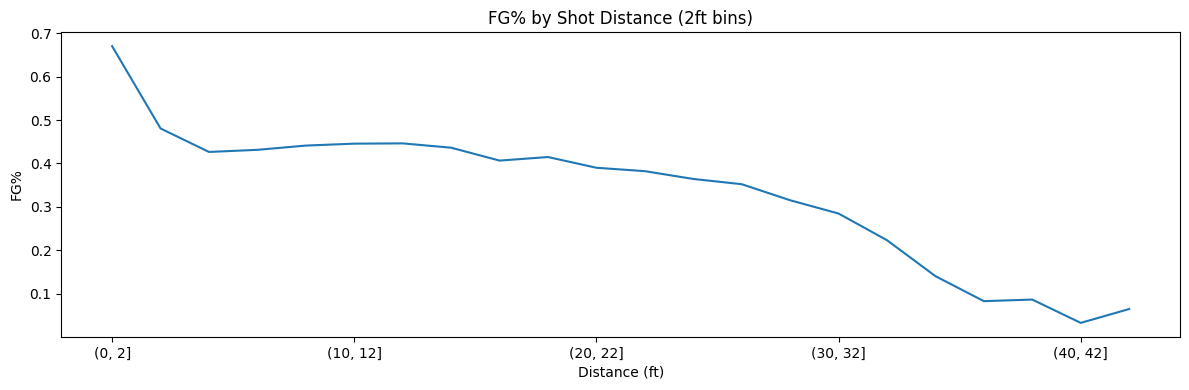

In [4]:
df["distance_bin"] = pd.cut(df["shot_distance"], bins=range(0, 45, 2))

dist_summary = (
    df.groupby("distance_bin")["shot_made_flag"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "fg_pct", "count": "attempts"})
)

dist_summary["fg_pct"].plot(figsize=(12, 4), title="FG% by Shot Distance (2ft bins)")
plt.ylabel("FG%")
plt.xlabel("Distance (ft)")
plt.tight_layout()
plt.show()

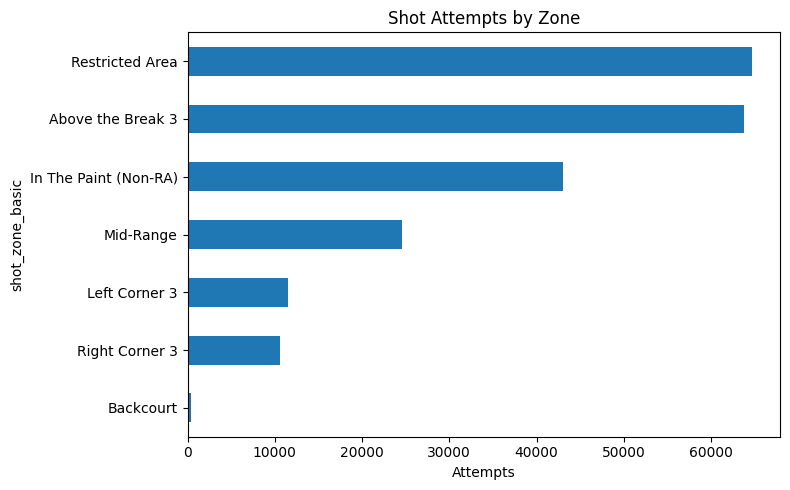

In [5]:
zone_summary["attempts"].sort_values().plot(
    kind="barh", figsize=(8, 5), title="Shot Attempts by Zone"
)
plt.xlabel("Attempts")
plt.tight_layout()
plt.show()

In [6]:
df.groupby("period")["shot_made_flag"].agg(["mean", "count"]).rename(
    columns={"mean": "fg_pct", "count": "attempts"}
)

,fg_pct,attempts
period,,
1,0.475179,56484
2,0.476583,54662
3,0.477688,54387
4,0.468788,51983
5,0.429942,1042
6,0.359155,142


In [7]:
df["shot_type"].value_counts(normalize=True).rename("proportion")

shot_type
2PT Field Goal    0.605144
3PT Field Goal    0.394856
Name: proportion, dtype: float64

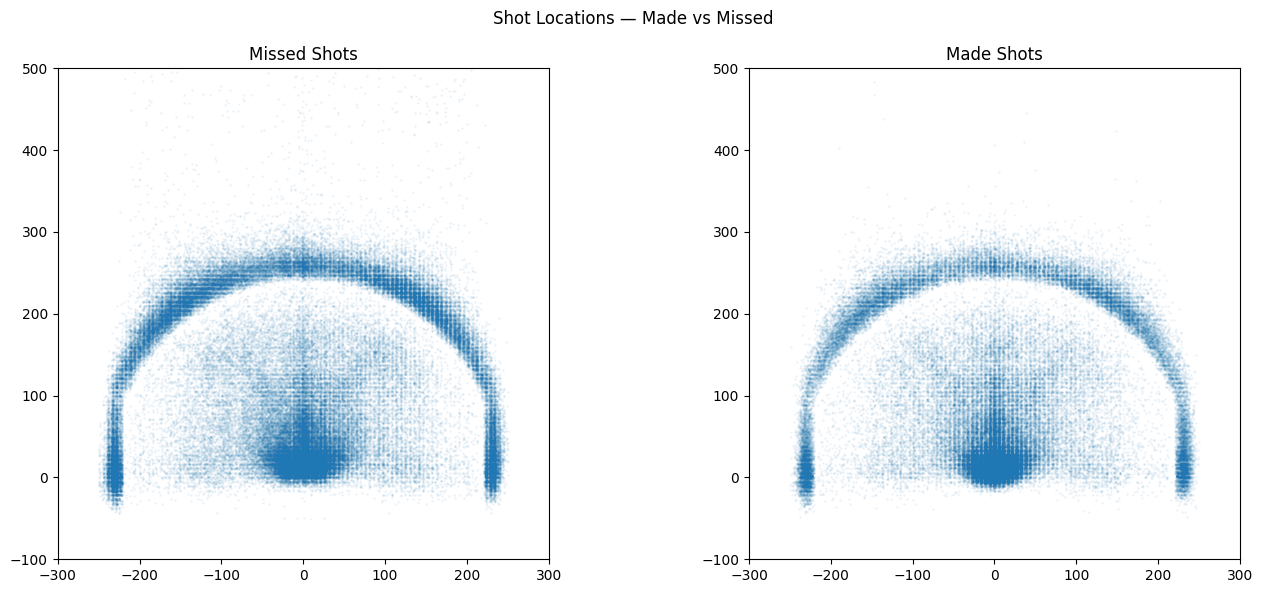

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, group) in zip(axes, df.groupby("shot_made_flag")):
    outcome = "Made" if label == 1 else "Missed"
    ax.scatter(group["loc_x"], group["loc_y"], alpha=0.05, s=1)
    ax.set_title(f"{outcome} Shots")
    ax.set_xlim(-300, 300)
    ax.set_ylim(-100, 500)
    ax.set_aspect("equal")

plt.suptitle("Shot Locations — Made vs Missed")
plt.tight_layout()
plt.show()

In [9]:
numeric_cols = ["shot_distance", "loc_x", "loc_y", "period", "minutes_remaining", "seconds_remaining"]
df[numeric_cols + ["shot_made_flag"]].corr()["shot_made_flag"].sort_values()

shot_distance       -0.229428
loc_y               -0.182181
period              -0.005242
loc_x                0.007343
seconds_remaining    0.010639
minutes_remaining    0.020854
shot_made_flag       1.000000
Name: shot_made_flag, dtype: float64